# Lab 4

In [283]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

In [284]:
# For this laboratory, there are different datasets that can be used.
# For now, we will use the raw_train dataset, which is the training set without any preprocessing.

raw_train_path = "./data/raw_train.csv"
train_summary_path = "./data/train_summary.csv"

raw_train = pd.read_csv(raw_train_path)
train_summary = pd.read_csv(train_summary_path)

## Data Cleaning

### Data Cleaning on the Raw Training Set

Get information about the dataset

In [285]:
raw_train.head(40)

,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015
3,1.0,1.0,BRIDGE,2018-01-18,453231.70,55,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_003537,JOB_002829__CON_000015
4,1.0,1.0,BRIDGE,2018-01-18,1513003.05,101,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001294,CON_000015,LOC_000028,ITEM_003537,JOB_001294__CON_000015
5,1.0,1.0,BRIDGE,2018-01-18,148876.00,20,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001298,CON_000015,LOC_000028,ITEM_003537,JOB_001298__CON_000015
6,1.0,1.0,BRIDGE,2018-01-18,453231.70,55,CONTRACT LIENS,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_001111,JOB_002829__CON_000015
7,1.0,1.0,BRIDGE,2018-01-18,148876.00,20,CONTRACT LIENS,$,31,ALTERNATES/BONUS/TIME,JOB_001298,CON_000015,LOC_000028,ITEM_001111,JOB_001298__CON_000015
8,1.0,1.0,BRIDGE,2018-01-18,1513003.05,101,CONTRACT LIENS,$,31,ALTERNATES/BONUS/TIME,JOB_001294,CON_000015,LOC_000028,ITEM_001111,JOB_001294__CON_000015
9,1.0,1.0,BRIDGE,2018-01-18,453231.70,55,QUALITY ADJUSTMENTS HMA,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_001362,JOB_002829__CON_000015


In [286]:
raw_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 832056 entries, 0 to 832055
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   quantity                  832056 non-null  float64
 1   amount                    832056 non-null  float64
 2   job_category_description  832056 non-null  object 
 3   bid_date                  832056 non-null  object 
 4   total_bid                 832056 non-null  float64
 5   num_pay_items             832056 non-null  int64  
 6   pay_item_description      832056 non-null  object 
 7   unit_english_id           832054 non-null  object 
 8   category_id               832056 non-null  int64  
 9   category_description      832056 non-null  object 
 10  job_id                    832056 non-null  object 
 11  contractor_id             832056 non-null  object 
 12  primary_location          832056 non-null  object 
 13  pay_item_id               832056 non-null  o

There are some null values on the unit_english_id column, which is 2 only rows. We can drop those rows without losing any information.

In [287]:
print(raw_train["unit_english_id"].isnull().sum())

# Drop the rows with null values in the unit_english_id column
raw_train = raw_train.dropna(subset=["unit_english_id"])

2


In [288]:
raw_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 832054 entries, 0 to 832055
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   quantity                  832054 non-null  float64
 1   amount                    832054 non-null  float64
 2   job_category_description  832054 non-null  object 
 3   bid_date                  832054 non-null  object 
 4   total_bid                 832054 non-null  float64
 5   num_pay_items             832054 non-null  int64  
 6   pay_item_description      832054 non-null  object 
 7   unit_english_id           832054 non-null  object 
 8   category_id               832054 non-null  int64  
 9   category_description      832054 non-null  object 
 10  job_id                    832054 non-null  object 
 11  contractor_id             832054 non-null  object 
 12  primary_location          832054 non-null  object 
 13  pay_item_id               832054 non-null  object

### Summary Training Set

In [289]:
# Check what columns train_summary actually has
print("train_summary columns:", train_summary.columns.tolist())
print("train_summary shape:", train_summary.shape)
print("\nraw_train columns:", raw_train.columns.tolist())
train_summary.head(5)

train_summary columns: ['job_id    ', 'contractor_id', 'total_bid             ', 'bid_date  ', 'primary_location', 'job_category_description']
train_summary shape: (10620, 6)

raw_train columns: ['quantity', 'amount', 'job_category_description', 'bid_date', 'total_bid', 'num_pay_items', 'pay_item_description', 'unit_english_id', 'category_id', 'category_description', 'job_id', 'contractor_id', 'primary_location', 'pay_item_id', 'row_id']


,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL


In [290]:
train_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_id                    10620 non-null  object 
 1   contractor_id             10620 non-null  object 
 2   total_bid                 10620 non-null  float64
 3   bid_date                  10620 non-null  object 
 4   primary_location          10620 non-null  object 
 5   job_category_description  10620 non-null  object 
dtypes: float64(1), object(5)
memory usage: 497.9+ KB


In [291]:
# Strip whitespace from column names, ensuring that aggregates later will work
raw_train.columns  = raw_train.columns.str.strip()
train_summary.columns = train_summary.columns.str.strip()

# raw_train uses row_id as "JOB_xxxxx__CON_xxxxx"
# Split into job_id and contractor_id
raw_train[["job_id", "contractor_id"]] = raw_train["row_id"].str.split("__", expand=True)

print("raw_train columns after split:", raw_train.columns.tolist())
raw_train.head(5)

raw_train columns after split: ['quantity', 'amount', 'job_category_description', 'bid_date', 'total_bid', 'num_pay_items', 'pay_item_description', 'unit_english_id', 'category_id', 'category_description', 'job_id', 'contractor_id', 'primary_location', 'pay_item_id', 'row_id']


,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015
3,1.0,1.0,BRIDGE,2018-01-18,453231.70,55,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_003537,JOB_002829__CON_000015
4,1.0,1.0,BRIDGE,2018-01-18,1513003.05,101,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001294,CON_000015,LOC_000028,ITEM_003537,JOB_001294__CON_000015


In [292]:
# Aggregate raw_train to bid level (job_id + contractor_id)
df_raw_agg = (
    raw_train
    .groupby(["job_id", "contractor_id"])
    .agg(
        row_id            = ("row_id",        "first"),
        num_pay_items     = ("pay_item_id",    "nunique"),
        total_quantity    = ("quantity",        "sum"),
        avg_quantity      = ("quantity",        "mean"),
        std_quantity      = ("quantity",        "std"),
        total_amount      = ("amount",          "sum"),
        avg_amount        = ("amount",          "mean"),
        std_amount        = ("amount",          "std"),
        unique_units      = ("unit_english_id", "nunique"),
        unique_categories = ("category_id",     "nunique"),
    )
    .reset_index()
)

df_raw_agg["std_quantity"] = df_raw_agg["std_quantity"].fillna(0)
df_raw_agg["std_amount"]   = df_raw_agg["std_amount"].fillna(0)

print(f"df_raw_agg shape : {df_raw_agg.shape}")
print(f"df_raw_agg columns : {df_raw_agg.columns.tolist()}")
df_raw_agg.head(5)

df_raw_agg shape : (10620, 12)
df_raw_agg columns : ['job_id', 'contractor_id', 'row_id', 'num_pay_items', 'total_quantity', 'avg_quantity', 'std_quantity', 'total_amount', 'avg_amount', 'std_amount', 'unique_units', 'unique_categories']


,job_id,contractor_id,row_id,num_pay_items,total_quantity,avg_quantity,std_quantity,total_amount,avg_amount,std_amount,unique_units,unique_categories
0,JOB_000001,CON_000047,JOB_000001__CON_000047,25,5974.0,238.960000,810.926848,106002.25,4240.090000,9417.063140,8,9
1,JOB_000001,CON_000091,JOB_000001__CON_000091,25,5974.0,238.960000,810.926848,122738.88,4909.555200,10795.590964,8,9
2,JOB_000001,CON_000137,JOB_000001__CON_000137,25,5974.0,238.960000,810.926848,60776.50,2431.060000,4591.283105,8,9
3,JOB_000002,CON_000001,JOB_000002__CON_000001,27,10014.1,370.892593,1786.950504,107295.00,3973.888889,8081.480511,8,13
4,JOB_000002,CON_000038,JOB_000002__CON_000038,27,10014.1,370.892593,1786.950504,64631.00,2393.740741,4696.994019,8,13


In [293]:
df_raw_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_id             10620 non-null  object 
 1   contractor_id      10620 non-null  object 
 2   row_id             10620 non-null  object 
 3   num_pay_items      10620 non-null  int64  
 4   total_quantity     10620 non-null  float64
 5   avg_quantity       10620 non-null  float64
 6   std_quantity       10620 non-null  float64
 7   total_amount       10620 non-null  float64
 8   avg_amount         10620 non-null  float64
 9   std_amount         10620 non-null  float64
 10  unique_units       10620 non-null  int64  
 11  unique_categories  10620 non-null  int64  
dtypes: float64(6), int64(3), object(3)
memory usage: 995.8+ KB


In [294]:
common_cols = set(train_summary.columns) & set(df_raw_agg.columns)
print(f"Common columns: {common_cols}")

Common columns: {'job_id', 'contractor_id'}


In [295]:
# Verify common columns before merge
print("train_summary columns:", train_summary.columns.tolist())
print("df_raw_agg columns   :", df_raw_agg.columns.tolist())

# Strip the column names to ensure that merging will work
train_summary["job_id"]        = train_summary["job_id"].str.strip()
train_summary["contractor_id"] = train_summary["contractor_id"].str.strip()
df_raw_agg["job_id"]           = df_raw_agg["job_id"].str.strip()
df_raw_agg["contractor_id"]    = df_raw_agg["contractor_id"].str.strip()

common_cols = set(train_summary.columns) & set(df_raw_agg.columns)
print(f"Common columns: {common_cols}")

# Merge
df = train_summary.merge(df_raw_agg, on=["job_id", "contractor_id"], how="left")

print(f"\nFinal df shape : {df.shape}")
print(f"Missing values :\n{df.isnull().sum()}")

assert df["total_bid"].isnull().sum() == 0, "Missing target values after merge!"
df.head(5)

train_summary columns: ['job_id', 'contractor_id', 'total_bid', 'bid_date', 'primary_location', 'job_category_description']
df_raw_agg columns   : ['job_id', 'contractor_id', 'row_id', 'num_pay_items', 'total_quantity', 'avg_quantity', 'std_quantity', 'total_amount', 'avg_amount', 'std_amount', 'unique_units', 'unique_categories']
Common columns: {'job_id', 'contractor_id'}

Final df shape : (10620, 16)
Missing values :
job_id                      0
contractor_id               0
total_bid                   0
bid_date                    0
primary_location            0
job_category_description    0
row_id                      0
num_pay_items               0
total_quantity              0
avg_quantity                0
std_quantity                0
total_amount                0
avg_amount                  0
std_amount                  0
unique_units                0
unique_categories           0
dtype: int64


,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description,row_id,num_pay_items,total_quantity,avg_quantity,std_quantity,total_amount,avg_amount,std_amount,unique_units,unique_categories
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000047,25,5974.0,238.960000,810.926848,106002.25,4240.090000,9417.063140,8,9
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000091,25,5974.0,238.960000,810.926848,122738.88,4909.555200,10795.590964,8,9
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000137,25,5974.0,238.960000,810.926848,60776.50,2431.060000,4591.283105,8,9
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000001,27,10014.1,370.892593,1786.950504,107295.00,3973.888889,8081.480511,8,13
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000038,27,10014.1,370.892593,1786.950504,64631.00,2393.740741,4696.994019,8,13


### DF Data Cleaning

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_id                    10620 non-null  object 
 1   contractor_id             10620 non-null  object 
 2   total_bid                 10620 non-null  float64
 3   bid_date                  10620 non-null  object 
 4   primary_location          10620 non-null  object 
 5   job_category_description  10620 non-null  object 
 6   row_id                    10620 non-null  object 
 7   num_pay_items             10620 non-null  int64  
 8   total_quantity            10620 non-null  float64
 9   avg_quantity              10620 non-null  float64
 10  std_quantity              10620 non-null  float64
 11  total_amount              10620 non-null  float64
 12  avg_amount                10620 non-null  float64
 13  std_amount                10620 non-null  float64
 14  unique

In [297]:
df.isnull().sum()

job_id                      0
contractor_id               0
total_bid                   0
bid_date                    0
primary_location            0
job_category_description    0
row_id                      0
num_pay_items               0
total_quantity              0
avg_quantity                0
std_quantity                0
total_amount                0
avg_amount                  0
std_amount                  0
unique_units                0
unique_categories           0
dtype: int64

In [298]:
df.isna().sum()

job_id                      0
contractor_id               0
total_bid                   0
bid_date                    0
primary_location            0
job_category_description    0
row_id                      0
num_pay_items               0
total_quantity              0
avg_quantity                0
std_quantity                0
total_amount                0
avg_amount                  0
std_amount                  0
unique_units                0
unique_categories           0
dtype: int64

In [299]:
df.duplicated().sum()

np.int64(0)

No null and duplicated columns. Let's parse the date into datetime.

In [300]:
df["bid_date"] = pd.to_datetime(df["bid_date"], errors="coerce")

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   job_id                    10620 non-null  object        
 1   contractor_id             10620 non-null  object        
 2   total_bid                 10620 non-null  float64       
 3   bid_date                  10620 non-null  datetime64[ns]
 4   primary_location          10620 non-null  object        
 5   job_category_description  10620 non-null  object        
 6   row_id                    10620 non-null  object        
 7   num_pay_items             10620 non-null  int64         
 8   total_quantity            10620 non-null  float64       
 9   avg_quantity              10620 non-null  float64       
 10  std_quantity              10620 non-null  float64       
 11  total_amount              10620 non-null  float64       
 12  avg_amount        

## Feature Engineering

Create new columns based on the columns we have.

Separate the bid_date column into year, month and day columns.

In [302]:
df["bid_month"] = df["bid_date"].dt.month
df["bid_year"] = df["bid_date"].dt.year
df["bid_day"] = df["bid_date"].dt.dayofweek

Have aggregate based features

In [303]:
# Contractor-based analysis:
# total number of bids per contractor
df["contractor_bid_count"] = df.groupby("contractor_id")["row_id"].transform(
    "nunique"
)

# average bid per contractor
df["contractor_avg_bid"] = df.groupby("contractor_id")["total_bid"].transform(
    "mean"
)

# median bid per contractor
df["contractor_median_bid"] = df.groupby("contractor_id")["total_bid"].transform(
    "median"
)

# average bid amount per contractor
df["contractor_avg_amount"] = df.groupby("contractor_id")["total_amount"].transform(
    "mean"
)

# average bid amount per contractor
df["contractor_avg_quantity"] = df.groupby("contractor_id")["total_quantity"].transform(
    "mean"
)

# Location based aggregates

# Total Bids per location
df["location_bid_count"] = df.groupby("primary_location")["row_id"].transform("count")

# Median Bids per location
df["location_bid_median"] = df.groupby("primary_location")["total_bid"].transform("median")


# Job category-based aggregates

# Bid counts per category
df["category_bid_count"]      = df.groupby("job_category_description")["row_id"].transform("count")

# Bid Median per category
df["category_median_bid"]     = df.groupby("job_category_description")["total_bid"].transform("median")

Preview that the new features have been created correctly.

In [304]:
df.head(15)

,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description,row_id,num_pay_items,total_quantity,avg_quantity,...,bid_day,contractor_bid_count,contractor_avg_bid,contractor_median_bid,contractor_avg_amount,contractor_avg_quantity,location_bid_count,location_bid_median,category_bid_count,category_median_bid
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000047,25,5974.0,238.960000,...,2,58,8.085200e+06,3303353.505,1.232667e+06,554436.416552,32,495431.500,135,535000.000
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000091,25,5974.0,238.960000,...,2,6,1.300800e+06,616422.525,3.943380e+05,91228.628333,32,495431.500,135,535000.000
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000137,25,5974.0,238.960000,...,2,401,1.384060e+06,911500.000,2.877575e+05,54563.277409,32,495431.500,135,535000.000
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000001,27,10014.1,370.892593,...,2,142,1.405964e+06,903164.290,4.266981e+05,92028.672676,62,1158378.665,135,535000.000
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000038,27,10014.1,370.892593,...,2,73,1.345999e+06,939755.500,2.768026e+05,27315.334110,62,1158378.665,135,535000.000
5,JOB_000002,CON_000188,516170.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000188,27,10014.1,370.892593,...,2,984,4.102827e+06,2208161.990,7.248383e+05,446709.984218,62,1158378.665,135,535000.000
6,JOB_000003,CON_000094,793929.00,2024-04-10,LOC_000061,SIGNALIZATION,JOB_000003__CON_000094,16,6146.0,384.125000,...,2,117,1.358766e+06,638126.000,3.222319e+05,44013.743504,952,625990.500,642,559902.000
7,JOB_000003,CON_000137,2087204.00,2024-04-10,LOC_000061,SIGNALIZATION,JOB_000003__CON_000137,16,6146.0,384.125000,...,2,401,1.384060e+06,911500.000,2.877575e+05,54563.277409,952,625990.500,642,559902.000
8,JOB_000004,CON_000074,4390000.00,2024-03-20,LOC_000030,ASPHALT,JOB_000004__CON_000074,41,569948.0,13901.170732,...,2,101,3.737117e+06,2234000.000,9.531910e+05,285318.166990,156,1332227.805,2944,2527270.405
9,JOB_000004,CON_000188,2986210.00,2024-03-20,LOC_000030,ASPHALT,JOB_000004__CON_000188,41,569948.0,13901.170732,...,2,984,4.102827e+06,2208161.990,7.248383e+05,446709.984218,156,1332227.805,2944,2527270.405


In [305]:
df

,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description,row_id,num_pay_items,total_quantity,avg_quantity,...,bid_day,contractor_bid_count,contractor_avg_bid,contractor_median_bid,contractor_avg_amount,contractor_avg_quantity,location_bid_count,location_bid_median,category_bid_count,category_median_bid
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000047,25,5974.0,238.960000,...,2,58,8.085200e+06,3303353.505,1.232667e+06,554436.416552,32,495431.500,135,535000.000
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000091,25,5974.0,238.960000,...,2,6,1.300800e+06,616422.525,3.943380e+05,91228.628333,32,495431.500,135,535000.000
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL,JOB_000001__CON_000137,25,5974.0,238.960000,...,2,401,1.384060e+06,911500.000,2.877575e+05,54563.277409,32,495431.500,135,535000.000
3,JOB_000002,CON_000001,400514.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000001,27,10014.1,370.892593,...,2,142,1.405964e+06,903164.290,4.266981e+05,92028.672676,62,1158378.665,135,535000.000
4,JOB_000002,CON_000038,293475.00,2024-07-10,LOC_000012,EROSION CONTROL,JOB_000002__CON_000038,27,10014.1,370.892593,...,2,73,1.345999e+06,939755.500,2.768026e+05,27315.334110,62,1158378.665,135,535000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,JOB_003712,CON_000158,1672400.00,2022-11-16,LOC_000090,GRADING/EXCAVATION,JOB_003712__CON_000158,62,37241.0,600.661290,...,2,1097,4.693265e+06,2278435.000,9.774917e+05,410769.716320,176,1674263.270,167,1859038.840
10616,JOB_003712,CON_000194,3284223.60,2022-11-16,LOC_000090,GRADING/EXCAVATION,JOB_003712__CON_000194,62,37241.0,600.661290,...,2,299,2.363686e+06,1462252.520,4.173557e+05,275819.739682,176,1674263.270,167,1859038.840
10617,JOB_003712,CON_000215,1629039.71,2022-11-16,LOC_000090,GRADING/EXCAVATION,JOB_003712__CON_000215,62,37241.0,600.661290,...,2,271,4.660412e+06,2800711.130,1.587790e+06,298622.700609,176,1674263.270,167,1859038.840
10618,JOB_003713,CON_000158,2834233.89,2020-02-05,LOC_000008,ASPHALT,JOB_003713__CON_000158,70,915292.0,13075.600000,...,2,1097,4.693265e+06,2278435.000,9.774917e+05,410769.716320,131,3158116.370,2944,2527270.405


## Visualization

In [306]:
# Extracting numeric and categorical columns for further analysis

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

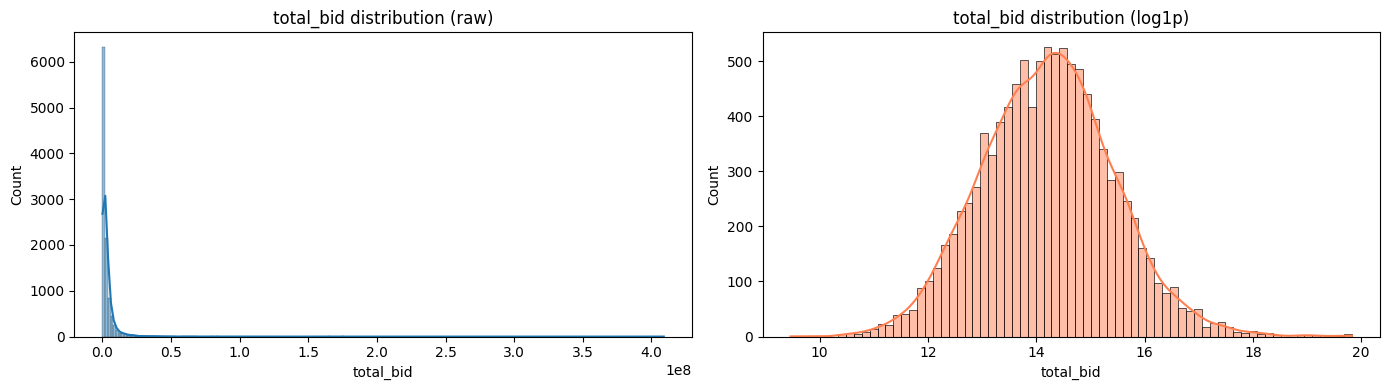

Skewness (raw)   : 21.1200
Skewness (log1p) : 0.1551


In [307]:
# Check skewness of target — important for choosing model/loss
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["total_bid"], kde=True, ax=axes[0])
axes[0].set_title("total_bid distribution (raw)")

sns.histplot(np.log1p(df["total_bid"]), kde=True, ax=axes[1], color="coral")
axes[1].set_title("total_bid distribution (log1p)")

plt.tight_layout()
plt.show()

print(f"Skewness (raw)   : {df['total_bid'].skew():.4f}")
print(f"Skewness (log1p) : {np.log1p(df['total_bid']).skew():.4f}")

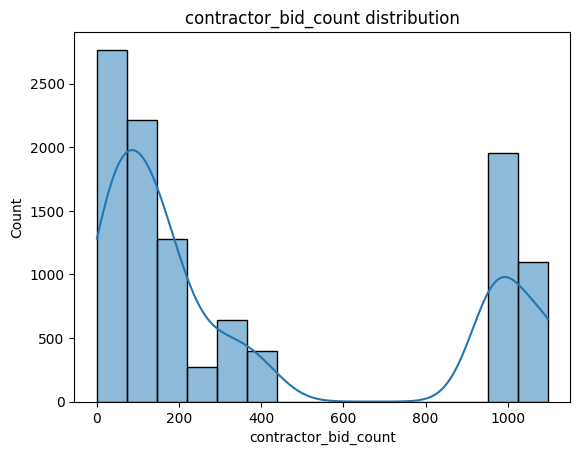

In [308]:
# What is the total number of bids per contractor?
sns.histplot(df["contractor_bid_count"], kde=True)
plt.title("contractor_bid_count distribution")
plt.show()

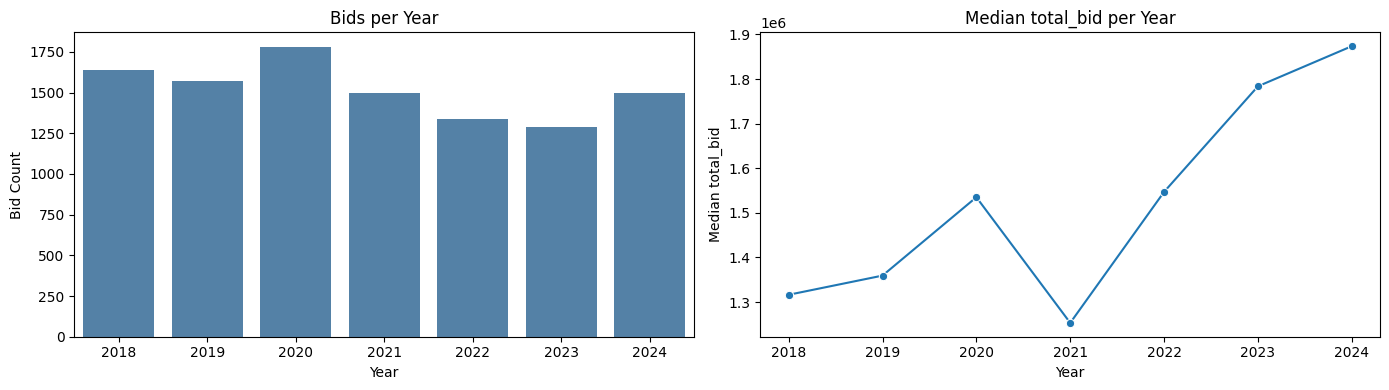

In [309]:
# Time-based analysis: per year and per month
df_time = df.copy()
df_time["bid_date"] = pd.to_datetime(df_time["bid_date"], errors="coerce")
df_time = df_time.dropna(subset=["bid_date"])

# Yearly aggregates
df_yearly = (
    df_time.assign(bid_year=df_time["bid_date"].dt.year)
    .groupby("bid_year", as_index=False)
    .agg(
        avg_total_bid=("total_bid", "mean"),
        median_total_bid=("total_bid", "median"),
        bid_count=("row_id", "count"),
    )
)

# Per-year visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=df_yearly, x="bid_year", y="bid_count", ax=axes[0], color="steelblue")
axes[0].set_title("Bids per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Bid Count")

sns.lineplot(
    data=df_yearly, x="bid_year", y="median_total_bid", marker="o", ax=axes[1]
)
axes[1].set_title("Median total_bid per Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Median total_bid")

plt.tight_layout()
plt.show()

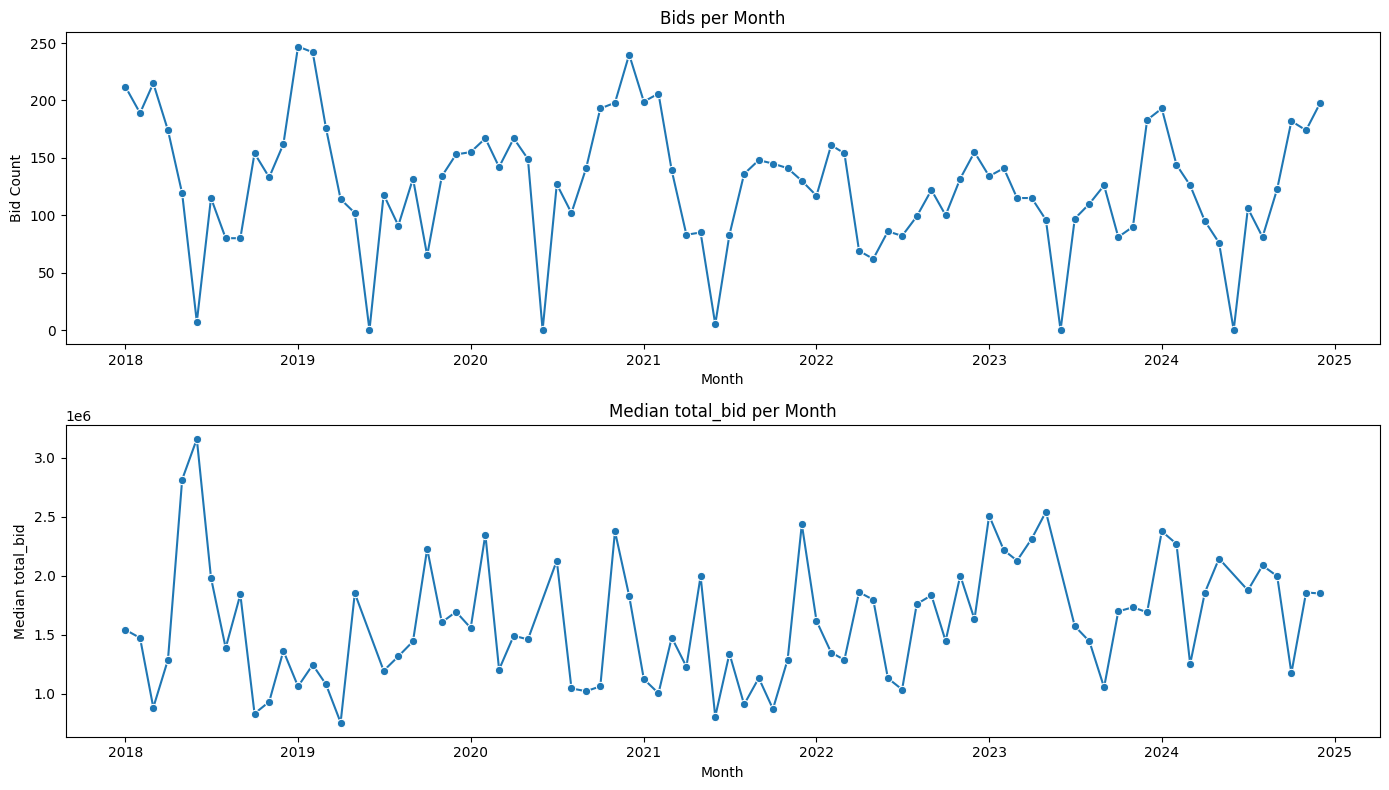

In [310]:
# Monthly aggregates
df_monthly = (
    df_time.set_index("bid_date")
    .resample("MS")
    .agg(
        avg_total_bid=("total_bid", "mean"),
        median_total_bid=("total_bid", "median"),
        bid_count=("row_id", "count"),
    )
    .reset_index()
)

# Per-month visualizations
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.lineplot(data=df_monthly, x="bid_date", y="bid_count", marker="o", ax=axes[0])
axes[0].set_title("Bids per Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Bid Count")

sns.lineplot(
    data=df_monthly, x="bid_date", y="median_total_bid", marker="o", ax=axes[1]
)
axes[1].set_title("Median total_bid per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Median total_bid")

plt.tight_layout()
plt.show()

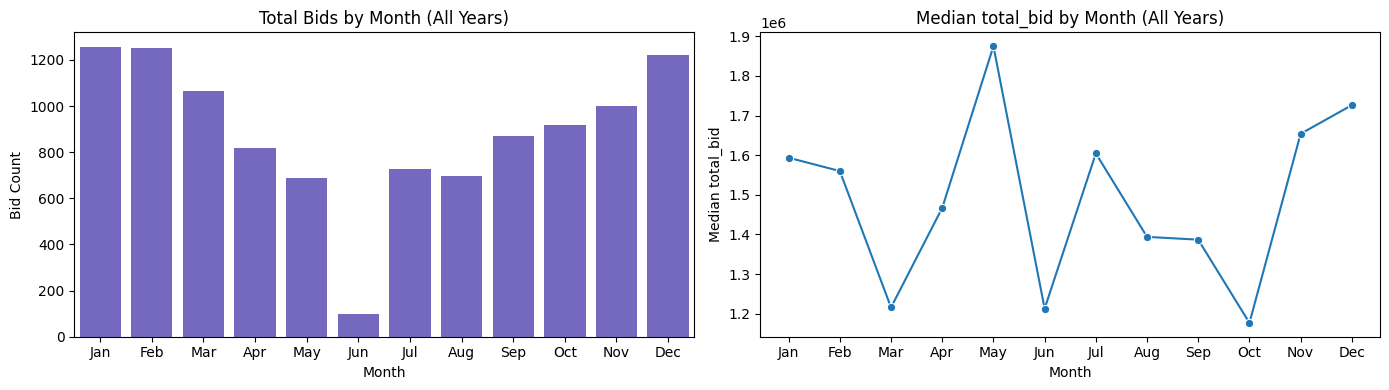

In [311]:
# Per-month aggregates (month-of-year, across all years)
df_monthly_seasonal = (
    df_time.assign(bid_month=df_time["bid_date"].dt.month)
    .groupby("bid_month", as_index=False)
    .agg(
        bid_count=("row_id", "count"),
        median_total_bid=("total_bid", "median"),
    )
)

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
df_monthly_seasonal["month_name"] = df_monthly_seasonal["bid_month"].map(month_map)

# Per-month visualizations (seasonality across all years)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=df_monthly_seasonal,
    x="month_name",
    y="bid_count",
    ax=axes[0],
    color="slateblue",
)
axes[0].set_title("Total Bids by Month (All Years)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Bid Count")

sns.lineplot(
    data=df_monthly_seasonal,
    x="month_name",
    y="median_total_bid",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Median total_bid by Month (All Years)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Median total_bid")

plt.tight_layout()
plt.show()

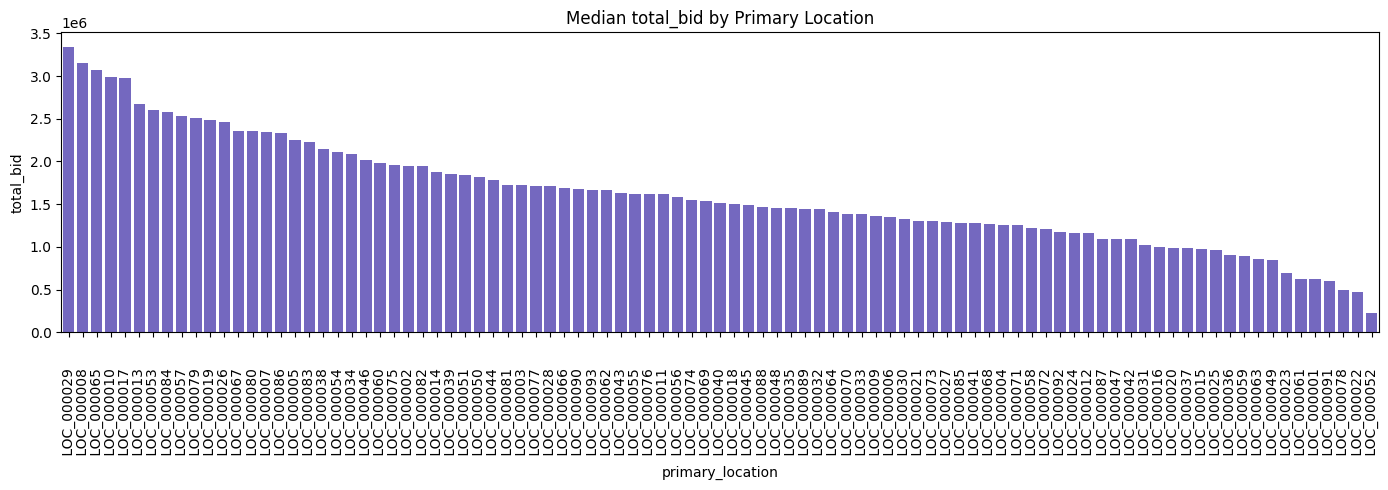

In [312]:
# Median total_bid per primary_location
df_location = (
    df.groupby("primary_location")["total_bid"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_location, x="primary_location", y="total_bid", color="slateblue"
)
plt.title("Median total_bid by Primary Location")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

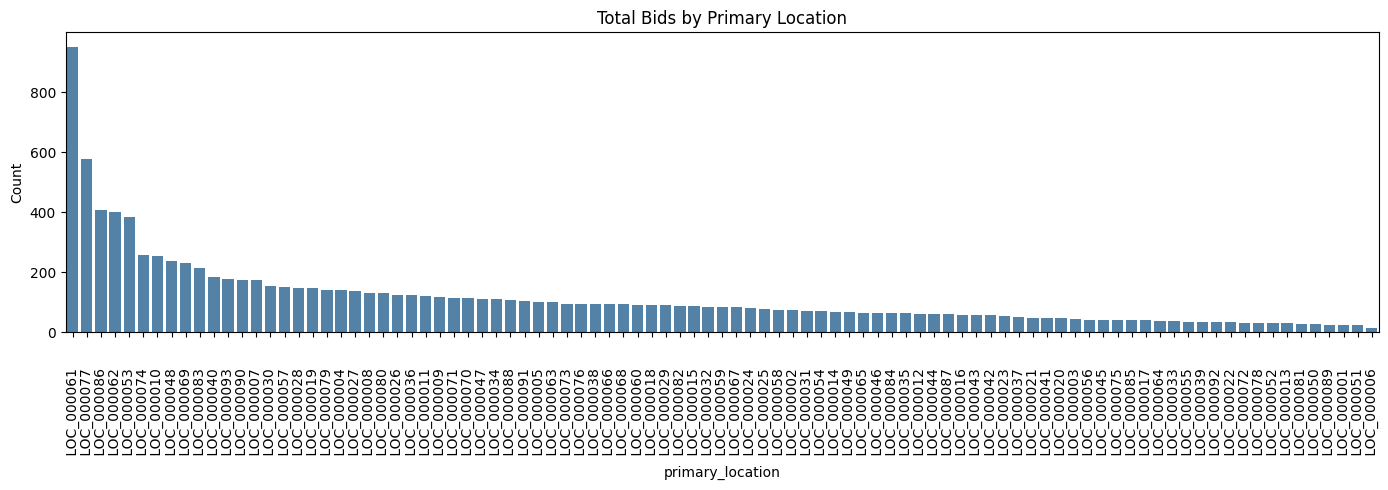

In [313]:
# Count the total amount of bids per primary_location
df_location_count = (
    df.groupby("primary_location")["row_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.barplot(
    data=df_location_count, x="primary_location", y="row_id", color="steelblue"
)
plt.title("Total Bids by Primary Location")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [314]:
len(df["primary_location"].unique())

93

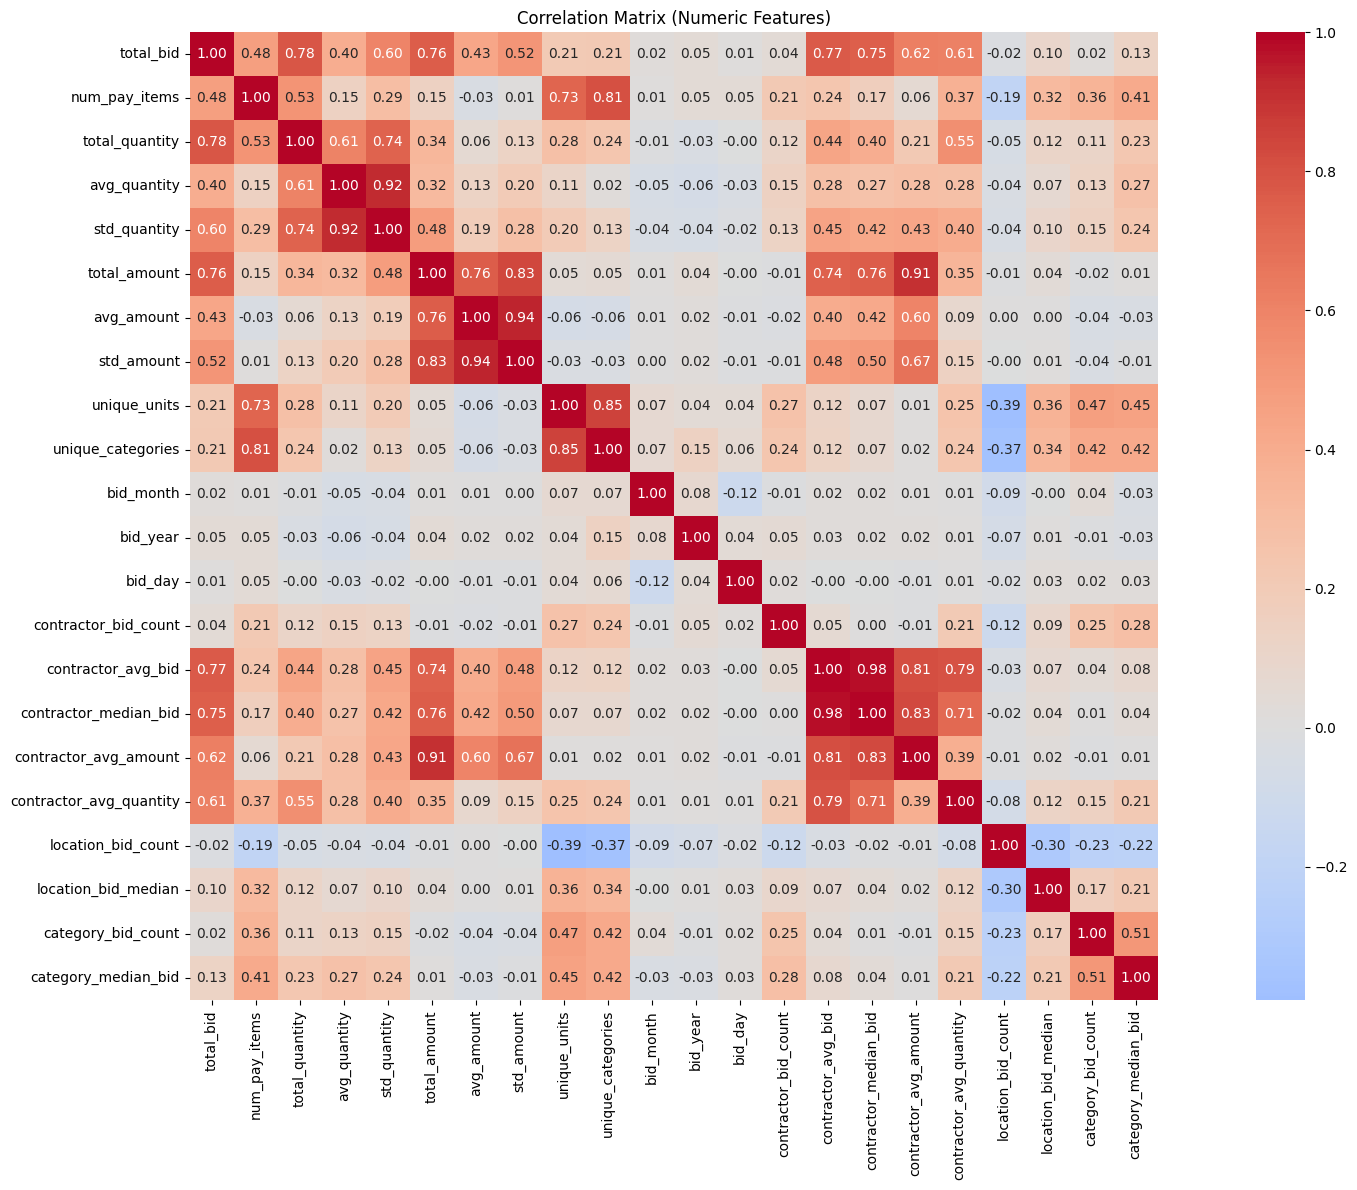

In [315]:
# Correlation of numeric features with total_bid
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(20, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [316]:

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"{col}: {n_outliers:,} outliers ({n_outliers / len(df) * 100:.2f}%)")

total_bid: 959 outliers (9.03%)
num_pay_items: 317 outliers (2.98%)
total_quantity: 1,317 outliers (12.40%)
avg_quantity: 1,273 outliers (11.99%)
std_quantity: 1,194 outliers (11.24%)
total_amount: 1,031 outliers (9.71%)
avg_amount: 1,023 outliers (9.63%)
std_amount: 931 outliers (8.77%)
unique_units: 5 outliers (0.05%)
unique_categories: 0 outliers (0.00%)
bid_month: 0 outliers (0.00%)
bid_year: 0 outliers (0.00%)
bid_day: 2,543 outliers (23.95%)
contractor_bid_count: 0 outliers (0.00%)
contractor_avg_bid: 98 outliers (0.92%)
contractor_median_bid: 297 outliers (2.80%)
contractor_avg_amount: 369 outliers (3.47%)
contractor_avg_quantity: 48 outliers (0.45%)
location_bid_count: 952 outliers (8.96%)
location_bid_median: 0 outliers (0.00%)
category_bid_count: 0 outliers (0.00%)
category_median_bid: 183 outliers (1.72%)


### Findings:

#### Target Variable
1. `total_bid` has a right-skewed distribution, which may indicate that there are outliers in the data. We may need to consider using a log transformation or other techniques to handle the skewness in our model.

#### Date related findings
1. The least number of bids that occur is on `June`, which is seen on the count and the median charts, which could mean that there is a low number of data (incomplete) or there is really not much bids happening on this month.
2. The bids on October and March has a low median `total_bid`, but has a high bid count. This could mean that although there are a lot of bids for these months, the projects here could be small, or less expensive overall.

#### Location based findings
1. `LOC_000061` contains the highest bid count, making it the most active location by far.
2. But based on the `total_bid` median chart, it has one of the lowest total bids from other locations. This would mean that the bids that are made for this location contain projects that may be small or less expensive.
3. `LOC_000029` contain the highest median `total_bid`, but the count of bids is found somewhere in the middle. This means that the bids made in this location could be relatively high.

#### Correlations
1. As seen in the correlation matrix, the columns that contains a high correlation to the `total_bid` column are:
   - contractor_avg_quantity (0.61)
   - contractor_avg_amount (0.62)
   - contractor_median_bid (0.75)
   - contractor_avg_bid (0.77)
   - std_amount (0.52)
   - avg_amount (0.43)
   - total_amount (0.76)
   - std_quantity (0.60)
   - avg_quantity (0.40)
   - total_quantity (0.78)
  We can use these later as features for our model.

## Preprocessing

### Drop Unnecessary Columns

Drop identifier columns (`row_id`, `job_id`, `pay_item_id`) and `bid_date` (already decomposed into `bid_month`, `bid_year`, `bid_day`). Also drop `category_description` since it is redundant with the numeric `category_id`, and drop `contractor_id` since it has been encoded into aggregate features.

In [317]:
cols_to_drop = ["row_id", "job_id", "bid_date", "contractor_id"]

df_model = df.drop(columns=cols_to_drop)

print(f"Shape after dropping: {df_model.shape}")
df_model.dtypes

Shape after dropping: (10620, 24)


total_bid                   float64
primary_location             object
job_category_description     object
num_pay_items                 int64
total_quantity              float64
avg_quantity                float64
std_quantity                float64
total_amount                float64
avg_amount                  float64
std_amount                  float64
unique_units                  int64
unique_categories             int64
bid_month                     int32
bid_year                      int32
bid_day                       int32
contractor_bid_count          int64
contractor_avg_bid          float64
contractor_median_bid       float64
contractor_avg_amount       float64
contractor_avg_quantity     float64
location_bid_count            int64
location_bid_median         float64
category_bid_count            int64
category_median_bid         float64
dtype: object

In [318]:
df_model.columns

Index(['total_bid', 'primary_location', 'job_category_description',
       'num_pay_items', 'total_quantity', 'avg_quantity', 'std_quantity',
       'total_amount', 'avg_amount', 'std_amount', 'unique_units',
       'unique_categories', 'bid_month', 'bid_year', 'bid_day',
       'contractor_bid_count', 'contractor_avg_bid', 'contractor_median_bid',
       'contractor_avg_amount', 'contractor_avg_quantity',
       'location_bid_count', 'location_bid_median', 'category_bid_count',
       'category_median_bid'],
      dtype='object')

### Encode Categorical Features

Use one-hot encoding (`pd.get_dummies`) on the remaining nominal columns (`job_category_description`, `pay_item_description`, `unit_english_id`, `primary_location`).

In [319]:
# Do not include pay_item_description in the OHE as it has a very high cardinality (over 1000 unique values)

# cat_cols_to_ohe = [col for col in categorical_cols if col != "pay_item_description"]
cat_cols_to_ohe = [col for col in categorical_cols if col not in ["job_id", 'contractor_id', 'row_id']]

df_encoded = pd.get_dummies(df_model, columns=cat_cols_to_ohe, drop_first=True)

print(f"Shape before OHE : {df_model.shape}")
print(f"Shape after OHE  : {df_encoded.shape}")
print(f"New columns added: {df_encoded.shape[1] - df_model.shape[1]}")
df_encoded.dtypes

# Target encoding may be okay for pay_item_description,
# considering that OHE may add too many columns and cause the model to overfit.
# But for now, drop


Shape before OHE : (10620, 24)
Shape after OHE  : (10620, 134)
New columns added: 110


total_bid                                              float64
num_pay_items                                            int64
total_quantity                                         float64
avg_quantity                                           float64
std_quantity                                           float64
                                                        ...   
job_category_description_ SIGNS-PERMANENT                 bool
job_category_description_ STRIPING/PAVEMENT MARKING       bool
job_category_description_ TRAFFIC CONTROL                 bool
job_category_description_ UTILITY-WATER                   bool
job_category_description_ Uncategorized Project           bool
Length: 134, dtype: object

In [320]:
df_encoded.head(20)

,total_bid,num_pay_items,total_quantity,avg_quantity,std_quantity,total_amount,avg_amount,std_amount,unique_units,unique_categories,...,job_category_description_ GUARD RAIL,job_category_description_ MOBILIZATION,job_category_description_ PAINTING STRUCTURES,job_category_description_ RETAINING WALL,job_category_description_ SIGNALIZATION,job_category_description_ SIGNS-PERMANENT,job_category_description_ STRIPING/PAVEMENT MARKING,job_category_description_ TRAFFIC CONTROL,job_category_description_ UTILITY-WATER,job_category_description_ Uncategorized Project
0,213693.50,25,5974.0,238.960000,810.926848,106002.25,4240.090000,9417.063140,8,9,...,False,False,False,False,False,False,False,False,False,False
1,219935.95,25,5974.0,238.960000,810.926848,122738.88,4909.555200,10795.590964,8,9,...,False,False,False,False,False,False,False,False,False,False
2,188000.00,25,5974.0,238.960000,810.926848,60776.50,2431.060000,4591.283105,8,9,...,False,False,False,False,False,False,False,False,False,False
3,400514.00,27,10014.1,370.892593,1786.950504,107295.00,3973.888889,8081.480511,8,13,...,False,False,False,False,False,False,False,False,False,False
4,293475.00,27,10014.1,370.892593,1786.950504,64631.00,2393.740741,4696.994019,8,13,...,False,False,False,False,False,False,False,False,False,False
5,516170.00,27,10014.1,370.892593,1786.950504,155456.00,5757.629630,12323.505034,8,13,...,False,False,False,False,False,False,False,False,False,False
6,793929.00,16,6146.0,384.125000,1006.414287,127910.00,7994.375000,19050.893483,4,5,...,False,False,False,False,True,False,False,False,False,False
7,2087204.00,16,6146.0,384.125000,1006.414287,606309.00,37894.312500,89599.773925,4,5,...,False,False,False,False,True,False,False,False,False,False
8,4390000.00,41,569948.0,13901.170732,27869.638583,800429.25,19522.664634,88299.644145,8,6,...,False,False,False,False,False,False,False,False,False,False
9,2986210.00,41,569948.0,13901.170732,27869.638583,532014.59,12975.965610,57664.109053,8,6,...,False,False,False,False,False,False,False,False,False,False


### Handling of Outliers
TODO: Might not implement. All data may be valid, and the outliers may be important for the model to learn. We can try to implement it later if we have time, but for now we will just keep the outliers in the dataset.

In [321]:
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clean_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return clean_data

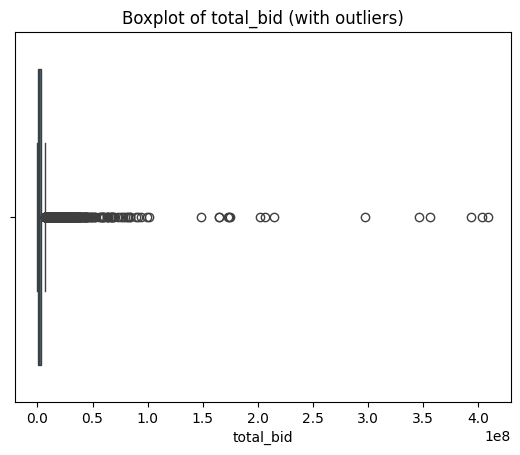

In [322]:
sns.boxplot(x=df["total_bid"])
plt.title("Boxplot of total_bid (with outliers)")
plt.show()

In [324]:
# for col in numeric_cols:
#     df_encoded = remove_outliers(df_encoded, col)

In [325]:
df_encoded.head(15)

,total_bid,num_pay_items,total_quantity,avg_quantity,std_quantity,total_amount,avg_amount,std_amount,unique_units,unique_categories,...,job_category_description_ GUARD RAIL,job_category_description_ MOBILIZATION,job_category_description_ PAINTING STRUCTURES,job_category_description_ RETAINING WALL,job_category_description_ SIGNALIZATION,job_category_description_ SIGNS-PERMANENT,job_category_description_ STRIPING/PAVEMENT MARKING,job_category_description_ TRAFFIC CONTROL,job_category_description_ UTILITY-WATER,job_category_description_ Uncategorized Project
0,213693.50,25,5974.0,238.960000,810.926848,106002.25,4240.090000,9417.063140,8,9,...,False,False,False,False,False,False,False,False,False,False
1,219935.95,25,5974.0,238.960000,810.926848,122738.88,4909.555200,10795.590964,8,9,...,False,False,False,False,False,False,False,False,False,False
2,188000.00,25,5974.0,238.960000,810.926848,60776.50,2431.060000,4591.283105,8,9,...,False,False,False,False,False,False,False,False,False,False
3,400514.00,27,10014.1,370.892593,1786.950504,107295.00,3973.888889,8081.480511,8,13,...,False,False,False,False,False,False,False,False,False,False
4,293475.00,27,10014.1,370.892593,1786.950504,64631.00,2393.740741,4696.994019,8,13,...,False,False,False,False,False,False,False,False,False,False
5,516170.00,27,10014.1,370.892593,1786.950504,155456.00,5757.629630,12323.505034,8,13,...,False,False,False,False,False,False,False,False,False,False
6,793929.00,16,6146.0,384.125000,1006.414287,127910.00,7994.375000,19050.893483,4,5,...,False,False,False,False,True,False,False,False,False,False
7,2087204.00,16,6146.0,384.125000,1006.414287,606309.00,37894.312500,89599.773925,4,5,...,False,False,False,False,True,False,False,False,False,False
8,4390000.00,41,569948.0,13901.170732,27869.638583,800429.25,19522.664634,88299.644145,8,6,...,False,False,False,False,False,False,False,False,False,False
9,2986210.00,41,569948.0,13901.170732,27869.638583,532014.59,12975.965610,57664.109053,8,6,...,False,False,False,False,False,False,False,False,False,False


## Training

### Define Features (X) and Target (y)

The target variable is `total_bid`. All remaining columns serve as features. The `amount` and `quantity` columns are kept as features since they are individual pay-item level values and do not directly equal `total_bid` at the row level (no leakage confirmed earlier).

In [326]:
TARGET = "total_bid"

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features shape : (10620, 133)
Target shape   : (10620,)

Feature columns:
['num_pay_items', 'total_quantity', 'avg_quantity', 'std_quantity', 'total_amount', 'avg_amount', 'std_amount', 'unique_units', 'unique_categories', 'bid_month', 'bid_year', 'bid_day', 'contractor_bid_count', 'contractor_avg_bid', 'contractor_median_bid', 'contractor_avg_amount', 'contractor_avg_quantity', 'location_bid_count', 'location_bid_median', 'category_bid_count', 'category_median_bid', 'primary_location_ LOC_000002      ', 'primary_location_ LOC_000003      ', 'primary_location_ LOC_000004      ', 'primary_location_ LOC_000005      ', 'primary_location_ LOC_000006      ', 'primary_location_ LOC_000007      ', 'primary_location_ LOC_000008      ', 'primary_location_ LOC_000009      ', 'primary_location_ LOC_000010      ', 'primary_location_ LOC_000011      ', 'primary_location_ LOC_000012      ', 'primary_location_ LOC_000013      ', 'primary_location_ LOC_000014      ', 'primary_location_ LOC_000015     

### Train / Test Split (80 / 20)

Split the data before any fit-based preprocessing (scaling) to prevent data leakage. Using `shuffle=True` to avoid ordering bias and `random_state=42` for reproducibility.

In [327]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (8496, 133)
X_test  : (2124, 133)
y_train : (8496,)
y_test  : (2124,)


In [328]:
from sklearn.preprocessing import StandardScaler

# Identify numeric columns to scale (exclude OHE dummy columns)
cols_to_scale = [
    "quantity", "amount", "bid_month", "bid_year", "bid_day",
    "contractor_bid_count", "contractor_avg_quantity", "contractor_avg_amount",
    "unit_bid_count", "unit_avg_quantity", "unit_avg_amount",
]

# Only scale columns that exist in X_train
cols_to_scale = [c for c in cols_to_scale if c in X_train.columns]

scaler = StandardScaler()

# Fit ONLY on train — prevents data leakage from test set
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")

X_train_scaled shape : (8496, 133)
X_test_scaled shape  : (2124, 133)


### Apply Linear Regression Model

In [329]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [330]:
# Train
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 5646714.714717553
Linear Regression R2: 0.7413390167293247
